In [2]:
import json
import matplotlib.pyplot as plt
import matplotlib as mpl
import numpy as np

In [3]:
def load_all_data_from_json(file_path):
    with open(file_path, "r") as file:
        data = json.load(file)
    return data

In [4]:
def load_values_from_json(file_path):
    with open(file_path, "r") as file:
        data_org = json.load(file)
    #return list(data_org.values())
    return [v for k, v in data_org.items() if "normalized" in k]

In [5]:
def get_files_with_cd(file_path, data_values, th):
    all_data = load_all_data_from_json(file_path)
    threshold = th
    keys_above_threshold = [key for key, value in all_data.items() if value > threshold]
    
    print(f"\nObjects whith Chamfer > {threshold}:")
    for key in keys_above_threshold:
        print(key)

    # Total number of files
    print(f"\nNumber of objects with Chamfer > {threshold}: {len(keys_above_threshold)} of {len(data_values)}")

In [6]:
def generate_histogram(data, bins, alpha, title, class_labels, means, colors):
    bins = 50
    plt.figure(figsize=(8, 4))

    all_data = np.concatenate(data)
    bin_edges = np.histogram_bin_edges(all_data, bins=bins)

    for i in range(len(data)):
        plt.hist(data[i], bins=bin_edges, alpha=alpha, color=colors[i], label=class_labels[i])
    for i in range(len(data)):    
        plt.axvline(means[i], color=colors[i], linestyle='--', linewidth=1.5, label=f"{class_labels[i]} Mean: {round(means[i], 4)}")

    # Add legend and labels
    plt.legend()
    plt.xlabel('Chamfer Distance Results')
    plt.ylabel('Frequency')
    plt.title(title)
    plt.show()

In [7]:
mpl.rcParams.update({
    'svg.fonttype': 'none',        # texto editable en SVG
    'pdf.fonttype': 42,            # texto como texto, no curvas
    'font.family': 'STIXGeneral',  # "Times-like" portátil
    'mathtext.fontset': 'stix'
})

In [8]:
def generate_histogram_and_save(data, bins, alpha, title, class_labels, means, colors, output_path):
    
    bins = 50
    plt.figure(figsize=(6, 4))

    all_data = np.concatenate(data)
    bin_edges = np.histogram_bin_edges(all_data, bins=bins)

    for i in range(len(data)):
        plt.hist(data[i], bins=bin_edges, alpha=alpha, color=colors[i], label=class_labels[i])
    for i in range(len(data)):    
        plt.axvline(
            means[i],
            color=colors[i],
            linestyle='--',
            linewidth=1.5,
            label=f"{class_labels[i]} Mean: {means[i]:.5f}",
        )

    # Add legend and labels
    plt.legend()
    plt.xlabel('Chamfer Distance Results')
    plt.ylabel('Frequency')
    plt.title(title)
    plt.tight_layout()

    pdf_path = output_path.replace('.svg', '.pdf')
    plt.savefig(pdf_path, format='pdf', transparent=False)
    plt.show()
    plt.close()
    print(f"✅ Histograma guardado en: {output_path}")

# ShapeNet 1000 Objects

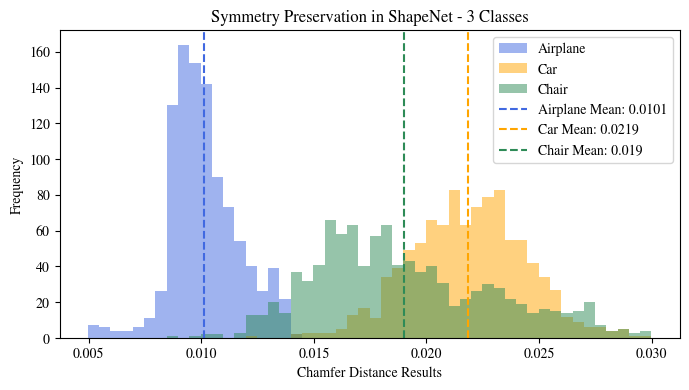

In [9]:
file_path_airplane = "shapenet_airplane.json"
shapenet1000_airplane_data = load_values_from_json(file_path_airplane)  # Limiting to 405 samples
airplane_mean = np.mean(shapenet1000_airplane_data)

file_path_car = "shapenet_car.json"
shapenet1000_car_data = load_values_from_json(file_path_car)  # Limiting to 405 samples
car_mean = np.mean(shapenet1000_car_data)

file_path_chair = "shapenet_chair.json"
shapenet1000_chair_data = load_values_from_json(file_path_chair)  # Limiting to 405 samples
chair_mean = np.mean(shapenet1000_chair_data)

data = [shapenet1000_airplane_data, shapenet1000_car_data, shapenet1000_chair_data]
class_labels = ["Airplane", "Car", "Chair"]
means = [airplane_mean, car_mean, chair_mean]
colors = ["royalblue", "orange", "seagreen"] # royalblue, darkorange, seagreen, indianred, mediumpurple, gold, teal, slateblue, lightcoral, darkkhaki

generate_histogram(data=data, bins=30, alpha=0.5, title="Symmetry Preservation in ShapeNet - 3 Classes", class_labels=class_labels, means=means, colors=colors)

# PVD

## Airplane

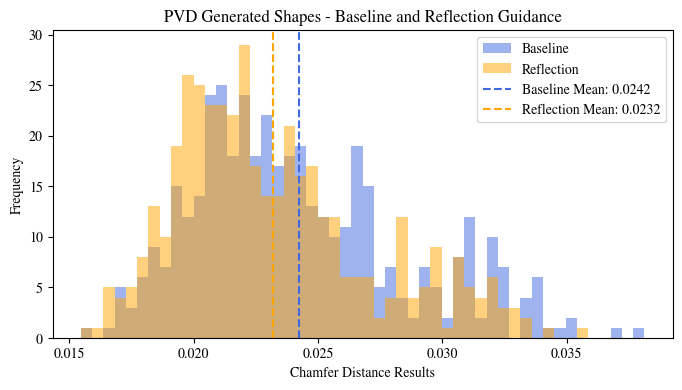

In [18]:
file_path = "/home/isipiran/LION_UG/guidance_results_3/baseline_scale1.0/chair/computed_mean_cd_per_sample.json"
pvd_baseline_airplane = load_values_from_json(file_path)
pvd_baeline_airplane_mean = np.mean(pvd_baseline_airplane)

file_path = "/home/isipiran/LION_UG/guidance_results_3/reflection_scale100.0/chair/computed_mean_cd_per_sample.json"
pvd_reflection_airplane = load_values_from_json(file_path)
pvd_reflection_airplane_mean = np.mean(pvd_reflection_airplane)

data = [pvd_baseline_airplane, pvd_reflection_airplane]
class_labels = ["Baseline", "Reflection"]
means = [pvd_baeline_airplane_mean, pvd_reflection_airplane_mean]
colors = ["royalblue", "orange"] # royalblue, darkorange, seagreen, indianred, mediumpurple, gold, teal, slateblue, lightcoral, darkkhaki

generate_histogram(data=data, bins=30, alpha=0.5, title="PVD Generated Shapes - Baseline and Reflection Guidance", class_labels=class_labels, means=means, colors=colors)

## Car

In [11]:
file_path = "/home/isipiran/LION_UG/guidance_results_2/baseline_scale1.0/airplane/computed_mean_cd_per_sample.json"
pvd_baseline_car = load_values_from_json(file_path)
pvd_baeline_car_mean = np.mean(pvd_baseline_car)

file_path = "/home/isipiran/LION_UG/guidance_results_2/reflection_scale1.0/airplane/computed_mean_cd_per_sample.json"
pvd_reflection_car = load_values_from_json(file_path)
pvd_reflection_car_mean = np.mean(pvd_reflection_car)

data = [pvd_baseline_car, pvd_reflection_car]
class_labels = ["Baseline", "Reflection"]
means = [pvd_baeline_car_mean, pvd_reflection_car_mean]
colors = ["royalblue", "orange"] # royalblue, darkorange, seagreen, indianred, mediumpurple, gold, teal, slateblue, lightcoral, darkkhaki

generate_histogram(data=data, bins=30, alpha=0.5, title="PVD Generated Shapes - Baseline and Reflection Guidance", class_labels=class_labels, means=means, colors=colors)

FileNotFoundError: [Errno 2] No such file or directory: '/home/isipiran/LION_UG/guidance_results_2/baseline_scale1.0/airplane/computed_mean_cd_per_sample.json'

## Chair

In [ ]:
file_path = "/home/isipiran/LION_necs/guidance_results/baseline_scale100.0/airplane/ours.json"
pvd_baseline_chair = load_values_from_json(file_path)
pvd_baeline_chair_mean = np.mean(pvd_baseline_chair)

file_path = "/home/isipiran/LION_necs/guidance_results/reflection_scale100.0/airplane/ours.json"
pvd_reflection_chair = load_values_from_json(file_path)
pvd_reflection_chair_mean = np.mean(pvd_reflection_chair)

data = [pvd_baseline_chair, pvd_reflection_chair]
class_labels = ["Baseline", "Reflection"]
means = [pvd_baeline_chair_mean, pvd_reflection_chair_mean]
colors = ["royalblue", "orange"] # royalblue, darkorange, seagreen, indianred, mediumpurple, gold, teal, slateblue, lightcoral, darkkhaki

generate_histogram(data=data, bins=30, alpha=0.5, title="PVD Generated Shapes - Baseline and Reflection Guidance", class_labels=class_labels, means=means, colors=colors)

FileNotFoundError: [Errno 2] No such file or directory: '/home/isipiran/LION_necs/guidance_results/baseline_scale100.0/airplane/ours.json'